# Aspen Mesh Brownbag
### 2020-04-01

### Covid-19 and the SARS-CoV-2 virus

In the United States, Covid-19 cases are reported to the CDC after testing positive on an FDA approved test. Testing requires a throat and nasal swab that takes a few minutes to collect. Test results are taking from 1-7 days, depending on region, case load, etc.

SARS-CoV-2 is the virus causing Covid-19. This seems to have been passed from animal (bat?) to human. It seems to be very easily passed from human to human, even when there are only minor or unnoticed symptoms in the humans carrying the virus.

### This morning, from Johns Hopkins CSSE

https://www.arcgis.com/apps/opsdashboard/index.html#/bda7594740fd40299423467b48e9ecf6

    Total Confirmed
    883,225
    Confirmed Cases by Country/Region/Sovereignty

    190,089 US
    105,792 Italy
    102,136 Spain
    82,361 China
    74,508 Germany
    52,836 France
    47,593 Iran
    29,842 United Kingdom
    17,137 Switzerland
    13,964 Belgium
    13,696 Netherlands
    13,531 Turkey
    10,501 Austria
    9,887 Korea, South
    ...

### This morning, from Colorado Case Summary (Updated 3/31/20 at 4:00 p.m.)

https://covid19.colorado.gov/case-data

Note: This summary only includes data through 3/30 and does not reflect cases since then.  

    2,966 cases*
    509 hospitalized
    50 counties
    16,849 people tested
    69 deaths 
    16 outbreaks at residential and non-hospital health care facilities

*The number of cases includes people who have had a test that indicated they were positive for COVID-19. The number of cases also includes epidemiologically-linked cases -- or cases where public health epidemiologists have determined that infection is highly likely because a person exhibited symptoms and had close contact with someone who tested positive. The number of epidemiologically-linked cases represents a very small portion of the reported cases.

### Exponential growth means infections grow quickly, as do errors in estimates

With exponential growth, uncertainties multiply and expand to huge values. This makes modeling and prediction prone to very large errors.

E.g. With doubling times and measured infection population size 10 days ago, we would predict 500k to 600k covid-19 infections today. There are only about 190k (thankfully!).

### Linear or slow exponential growth intuitions don't apply

Linear growth means we can manage things with proportional responses to data passing a threshold. Think of driving a car by looking out the window. You see you are going off the road, so you turn the wheel a little to correct.  Usually, the speed is low enough that something bad doesn't happen before you correct course. And the car steering responds without a relevant time delay to correct course with time to spare.

The key characteristic of rapid exponential growth is that the rate of change accelerates as the value increases:

$$f(t) = \exp(at)$$

$$\frac{df}{dt} = a\exp(at)$$

With rapid exponential growth, it is more useful to think in terms of doubling times:

$$f(t_1) = \exp(at_1)$$

$$f(t_2) = \exp(at_2) = 2f(t_1)$$

$$\log(2) + at_1 = at_2$$

$$\text{doubling time} = t_2-t_1 = \frac{\log(2)}{a}$$

### Asymptomatic infections confound modeling and prediction

Estimates of asymptomatic carriers are in the 50-80% of all infected. This makes selective quarantine more difficult as carriers don't know they are sick. The wide range of uncertainty means estimating what the population of infected and recovered people very uncertain.

## Exponential Growth in the US and doubling times

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # project root, so covid19 imports without installing
from covid19.data import get_state_df, us_states_daily, world_daily
from covid19.models import (SIR, describe_sir, estimate_current_cases, get_state_doubling_df,
                            get_zero_aligned_log_positive, period_factor_plot)

AS_OF = "2020-03-31"  # the data available the morning of the talk

In [2]:
df, states_in_order = us_states_daily(as_of=AS_OF)
df.tail()

,date,state,positive,negative,pending,tests,death,daily_new_positive,daily_new_death,population
1679,2020-03-27,WY,70.0,1211.0,0.0,2204.0,0.0,17,0,578759.0
1680,2020-03-28,WY,82.0,1475.0,0.0,2306.0,0.0,12,0,578759.0
1681,2020-03-29,WY,86.0,1554.0,0.0,2384.0,0.0,4,0,578759.0
1682,2020-03-30,WY,94.0,1840.0,0.0,2641.0,0.0,8,0,578759.0
1683,2020-03-31,WY,109.0,1999.0,0.0,2922.0,0.0,15,0,578759.0


In [3]:
dfus = get_state_df(df, "*", additional_aggregation_keys=["pending"])
dfus.tail()

,date,positive,daily_new_positive,death,daily_new_death,tests,pending
74,2020-03-27,111358.0,19215,1782.0,411,769985.0,59795.0
75,2020-03-28,131143.0,19785,2332.0,550,881415.0,65698.0
76,2020-03-29,150826.0,19683,2838.0,506,968389.0,65404.0
77,2020-03-30,171965.0,21139,3422.0,584,1068981.0,65369.0
78,2020-03-31,196965.0,25000,4331.0,909,1183548.0,59550.0


US Total Positive, doubling every 3.91 days as of 2020-03-31
  based on last 10 days of data


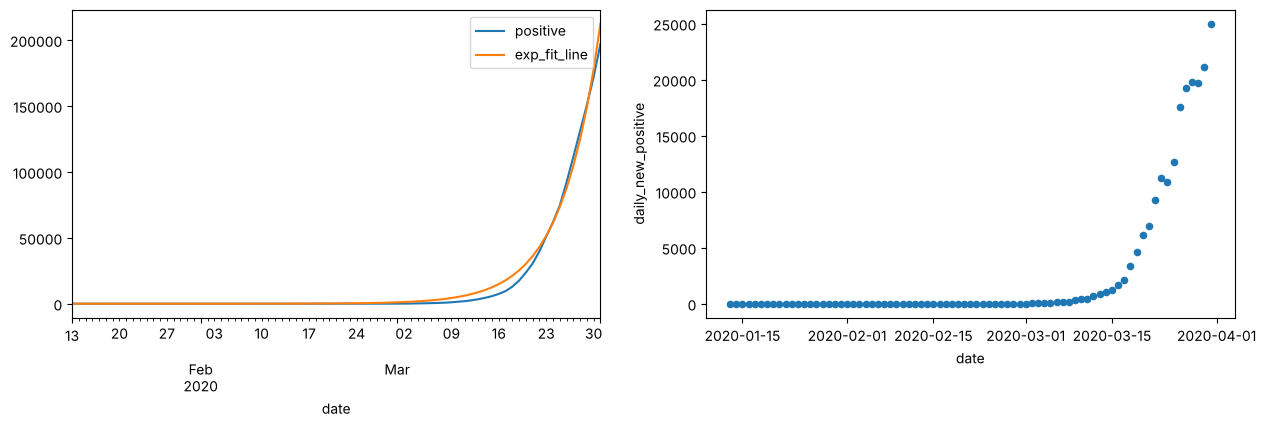

In [4]:
last_n_days = 10
dfa, dt, _ = get_state_doubling_df(df, "*", use_last_n_days=last_n_days)
print(f"US Total Positive, doubling every {dt:.2f} days as of {dfa.date.max():%Y-%m-%d}")
print(f"  based on last {last_n_days} days of data")
fig, axes = plt.subplots(1, 2, figsize=[15, 4])
dfa.plot(x="date", y=["positive", "exp_fit_line"], ax=axes[0])
dfa.plot.scatter(x="date", y="daily_new_positive", ax=axes[1])
plt.show()

### "Herd Immunity" and "Fewer deaths than the flu, right?"
The temptation to minimize until the problem is real? ("fewer deaths than the flu, right?"--yes, for a few more days this year). The rate of growth will surpass the average weekly rate of flu deaths in the US this week or early next and keep growing rapidly. Much too late for a "proportional response" to matter.

And "herd immunity" folks ("everyone is getting covid-19 anyway"--yes, unless we create a vaccine). 

#### The Goal: We are hoping to control for health system capacity, rather than total infections.

## Create a model that is more realistic around the entire population so we can predict demand on the healthcare system a few weeks out

1. A more realistic infection, immunity, recovery model than pure exponential growth
2. Parameters that give policy makers "levers to pull" to manage the demand on healthcare.

### SIR model

Exponential growth is a reasonable estimator early in an epidemic, because
the number of people susceptible people is the total number of people. In the US, with a population
of about 350M, a few thousand infections doesn't decrease the susceptible population much. 

With Covid-19, the recovery time is 7-14 days so removing people from the population due to immunity
is also not a deterrent to exponential growth at the start of an epidemic.

    N total population (constant)
    S is the susceptible population with time. At the start of Covid-19, this is assumed to be everyone.
      As time goes by, we assume exposed people are removed through recovery/immunity or death.
      
    I represents the number of infected individuals at a given time.
    
    R represents the population removed from S

### Infected population change with time...

1. with interactions of infected and susceptible people, $\beta$ and 
2. decreases with recovery or death $\gamma$

$$\frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I$$

### S and R...

$$\frac{dS}{dt} = \frac{-\beta S I}{N}$$

$$\frac{dR}{dt} = \gamma I$$

## Try the SIR model for the US

$$N = 330,000,000$$
$$R_0 = 0$$

Fit the model to the existing covid-19 cases data to date.

Assume we are catching 20% of actual cases. (The talk fit both β and γ; here γ is fixed at 1/10 per day, because
early-epidemic data only determine β − γ.)


In [5]:
pos_untested = 0.8   # 20% of actual cases
dfus["actual_pos"] = dfus.positive.values * (1 + pos_untested) / 1000   # population in thousands
dfus.tail()

,date,positive,daily_new_positive,death,daily_new_death,tests,pending,actual_pos
74,2020-03-27,111358.0,19215,1782.0,411,769985.0,59795.0,200.4444
75,2020-03-28,131143.0,19785,2332.0,550,881415.0,65698.0,236.0574
76,2020-03-29,150826.0,19683,2838.0,506,968389.0,65404.0,271.4868
77,2020-03-30,171965.0,21139,3422.0,584,1068981.0,65369.0,309.5370
78,2020-03-31,196965.0,25000,4331.0,909,1183548.0,59550.0,354.5370


In [6]:
N = 330_000  # total population in thousands
GAMMA = 0.1  # 1 / infectious period: fixed, since early data can't separate beta from gamma
c = np.trim_zeros(dfus.actual_pos.values, "f")
N, I0, R0, beta, gamma = SIR().SIRFitter(c, N, gamma=GAMMA)

### Fit parameters

In [7]:
print(describe_sir(beta, gamma, I0))

R0 = beta/gamma = 2.77; early doubling time ln2/(beta-gamma) = 3.9 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 0.189


## Compare Italy and Spain

In [8]:
dfw, _ = world_daily(as_of=AS_OF)
get_state_df(dfw, "Italy").tail()

,state,date,positive,death,daily_new_positive,daily_new_death
65,Italy,2020-03-27,86498,9134,5909.0,919.0
66,Italy,2020-03-28,92472,10023,5974.0,889.0
67,Italy,2020-03-29,97689,10779,5217.0,756.0
68,Italy,2020-03-30,101739,11591,4050.0,812.0
69,Italy,2020-03-31,105792,12428,4053.0,837.0


In [9]:
for country, N in [("Italy", 60_000), ("Spain", 47_000)]:   # population in thousands
    dfq = get_state_df(dfw, country)
    c = np.trim_zeros(dfq.positive.values * (1 + pos_untested) / 1000, "f")
    _, I0, _, beta, gamma = SIR().SIRFitter(c, N, gamma=GAMMA)
    print(f"{country}:", describe_sir(beta, gamma, I0))

Italy: R0 = beta/gamma = 3.30; early doubling time ln2/(beta-gamma) = 3.0 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 0.657
Spain: R0 = beta/gamma = 3.36; early doubling time ln2/(beta-gamma) = 2.9 days; mean infectious period 1/gamma = 10.0 days; initial infections ~ 0.161


## But quarantine and social distancing change beta over time...

Maybe add a 4th equation?
    
$$\frac{d\beta}{dt} = f(\text{behavior|death rate, overload on health care, economy...})$$

## What does the data show?

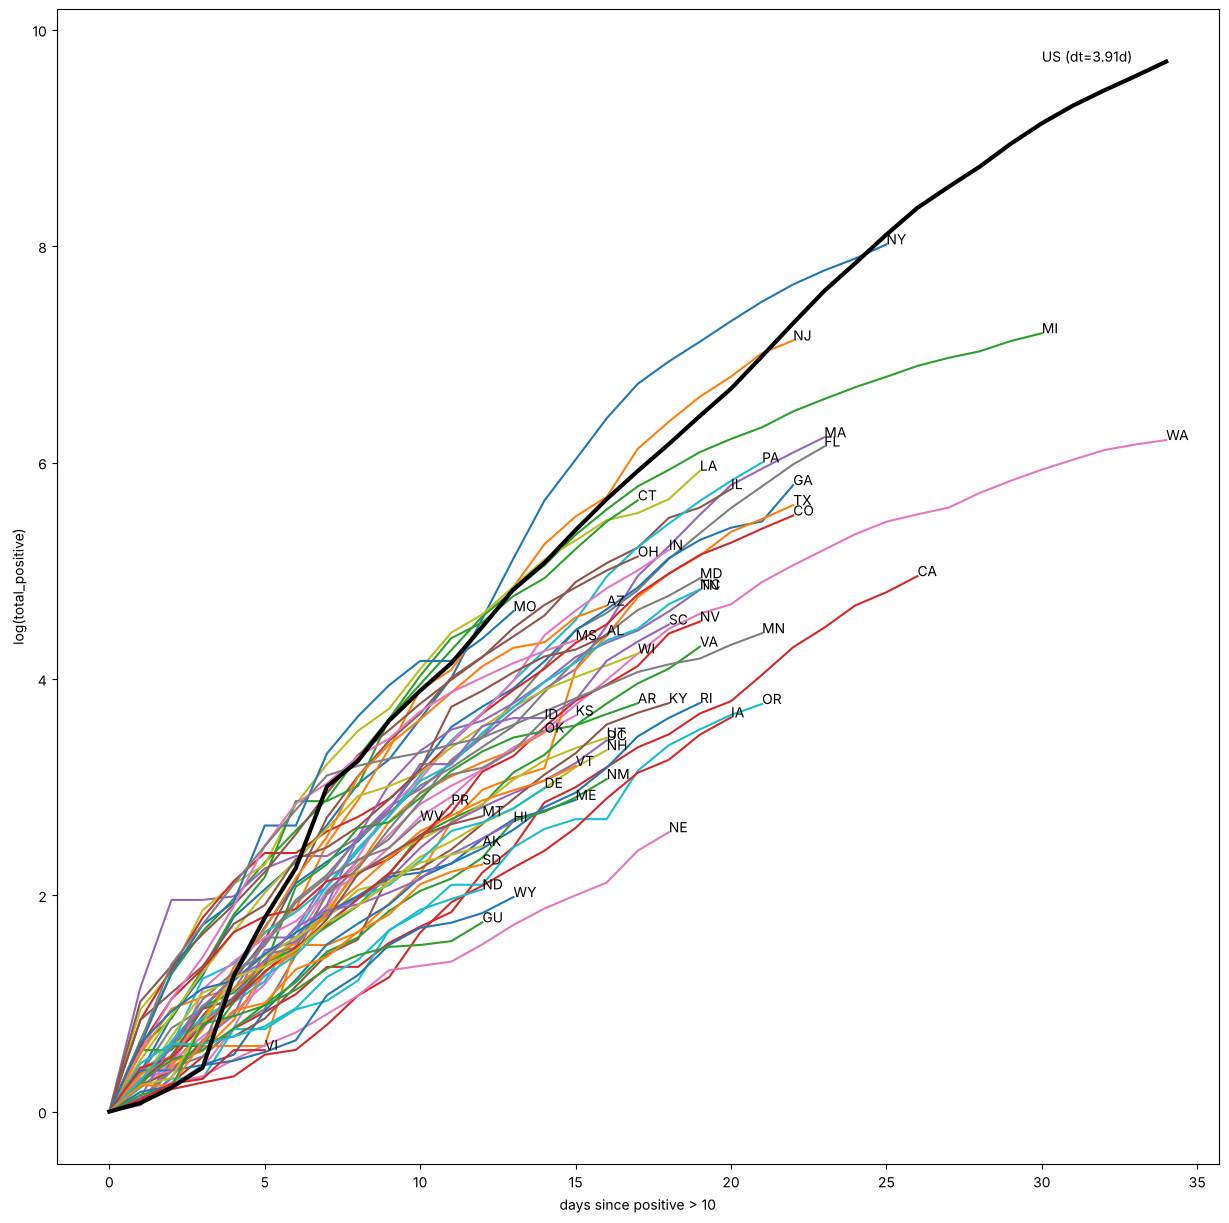

In [10]:
# start after day with min_pos or more cases
min_pos = 10
key_value = f"days_since_{min_pos}"

plt.figure(figsize=[15, 15])
for s in states_in_order:
    dfq = get_zero_aligned_log_positive(get_state_df(df, s), min_pos=min_pos)
    if len(dfq):
        plt.plot(dfq[key_value].values, dfq.log_positive.values)
        plt.annotate(s, (dfq[key_value].values[-1], dfq.log_positive.values[-1]))

dfq = get_zero_aligned_log_positive(dfus, min_pos=min_pos)
_, dt, _ = get_state_doubling_df(df, "*", use_last_n_days=10)
plt.plot(dfq[key_value].values, dfq.log_positive.values, "k", lw=3)
plt.annotate(f"US (dt={dt:1.2f}d)", (int(.9 * dfq[key_value].values[-1]), dfq.log_positive.values[-1]))
plt.xlabel(f"days since positive > {min_pos}")
plt.ylabel("log(total_positive)")
plt.show()

### State Doubling Times Today

In [11]:
last_n_days = 10
rows = []
for s in states_in_order:
    dfq, dt, _ = get_state_doubling_df(df, s, use_last_n_days=last_n_days)
    current, hospitalized, icu = estimate_current_cases(dfq.daily_new_positive.values)
    rows.append({"state": s, "positive": int(dfq.positive.iloc[-1]), "doubling_days": dt,
                 "unresolved (naive)": current, "hospitalized (naive)": hospitalized, "icu (naive)": icu})
state_table = pd.DataFrame(rows).set_index("state")
state_table.style.format({"doubling_days": "{:.1f}"}, na_rep="–")

,positive,doubling_days,unresolved (naive),hospitalized (naive),icu (naive)
state,,,,,
NY,75795,4.0,65439,9815,2617
NJ,18696,2.7,17369,2605,694
MI,18654,7.4,11631,1744,465
CA,7482,3.7,6203,930,248
MA,6620,2.5,6095,914,243
IL,5994,3.5,5241,786,209
WA,5957,7.6,3460,519,138
FL,5612,3.1,5084,762,203
LA,5237,3.6,4657,698,186


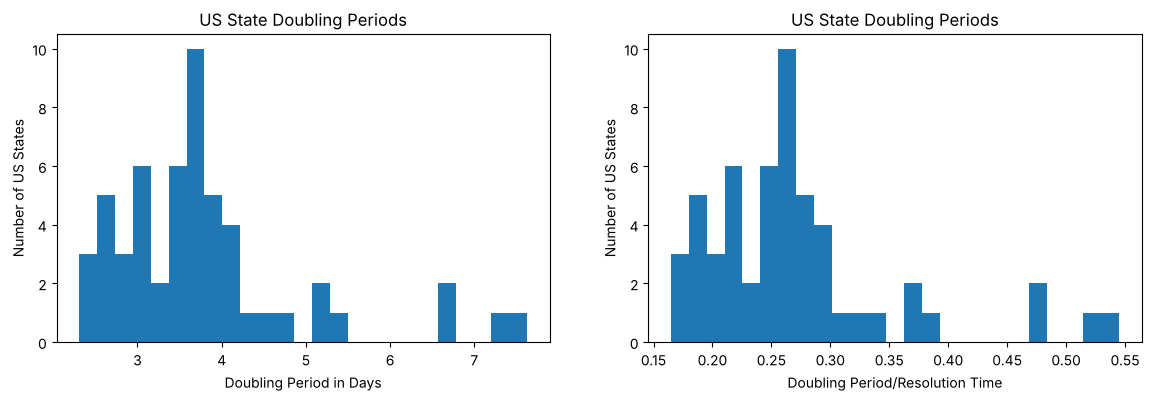

In [12]:
dps = state_table.doubling_days
dp_state = dps[(dps > 0) & (dps < 30)]
resolution_time = 14
fig, axes = plt.subplots(1, 2, figsize=[14, 4])
axes[0].hist(dp_state, bins=25)
axes[0].set_xlabel("Doubling Period in Days")
axes[1].hist(dp_state / resolution_time, bins=25)
axes[1].set_xlabel("Doubling Period/Resolution Time")
for ax in axes:
    ax.set_title("US State Doubling Periods")
    ax.set_ylabel("Number of US States")
plt.show()

### State Doubling Times (Moving Window)

Behavior changes reduce $\beta$ while leaving $\gamma$ constant (until we discover some behavior
that helps infected people recover faster).

This means that when we implement a policy (e.g. social distancing) the growth rate slows slightly, but
the characteristic recovery time does not change, so improvements show up a few days later.  A measure of this
reactivity is the relative to policy time scale:

$$ u = \frac{\gamma}{\beta} \approx \frac{\text{doubling time}}{\text{recovery time}}$$

Linear-style proportional response (e.g. test and quarantine infected, interview contacts) doesn't control the epidemic until $u \gg 1$.  Effective responses have to scale with the population until they are under more reactive control, hence, lockdowns and social distancing.

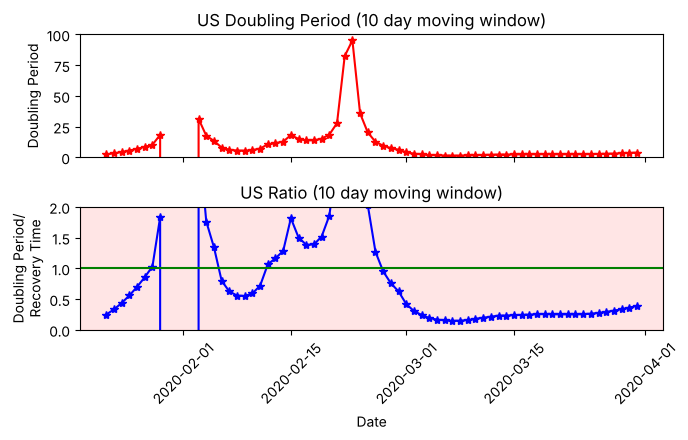

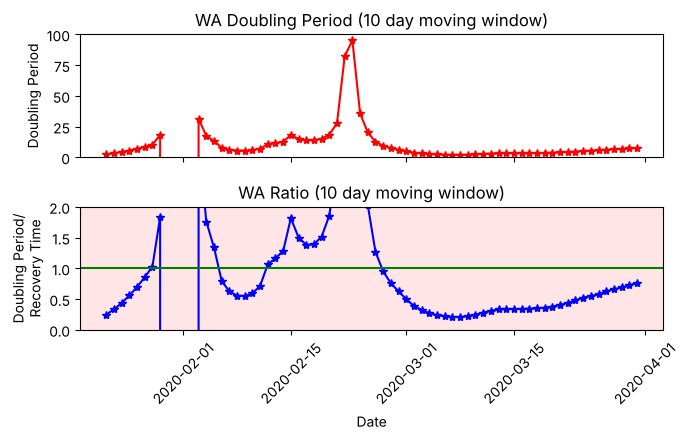

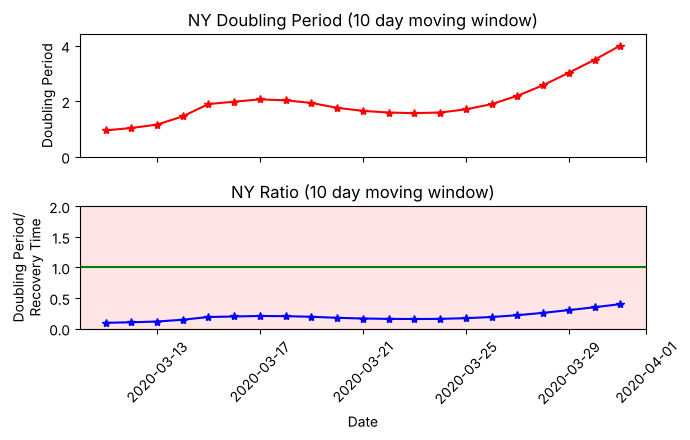

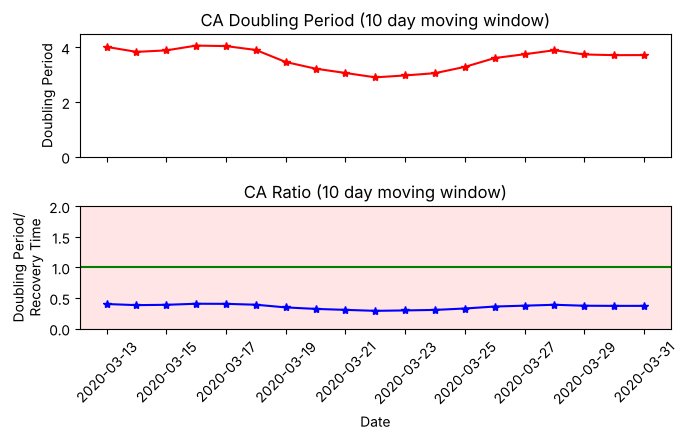

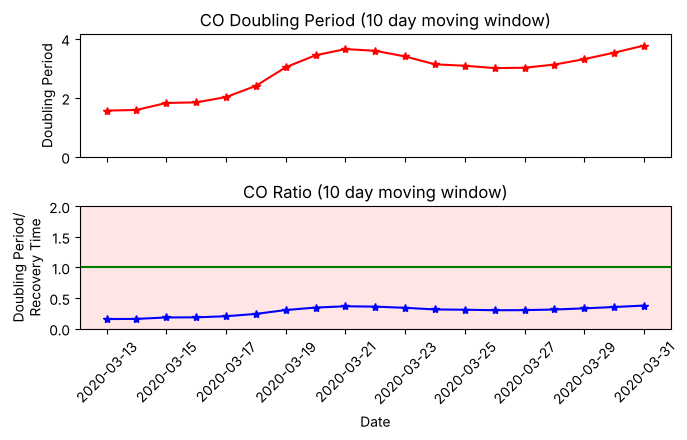

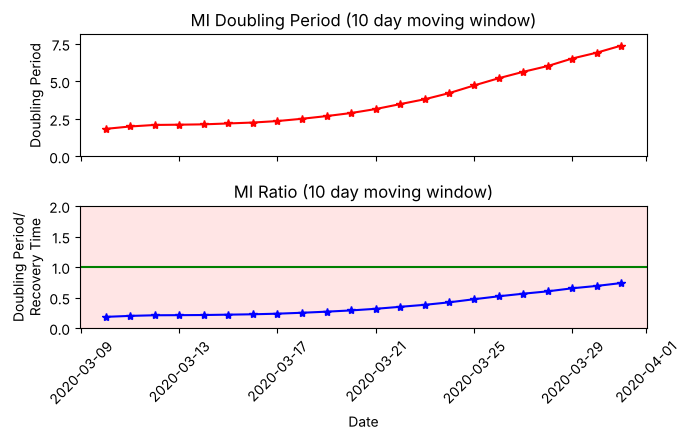

In [13]:
for s in ["*", "WA", "NY", "CA", "CO", "MI"]:
    period_factor_plot(df, s, ylimit=2)

### Testing is likely a major source of uncertainty in predictions

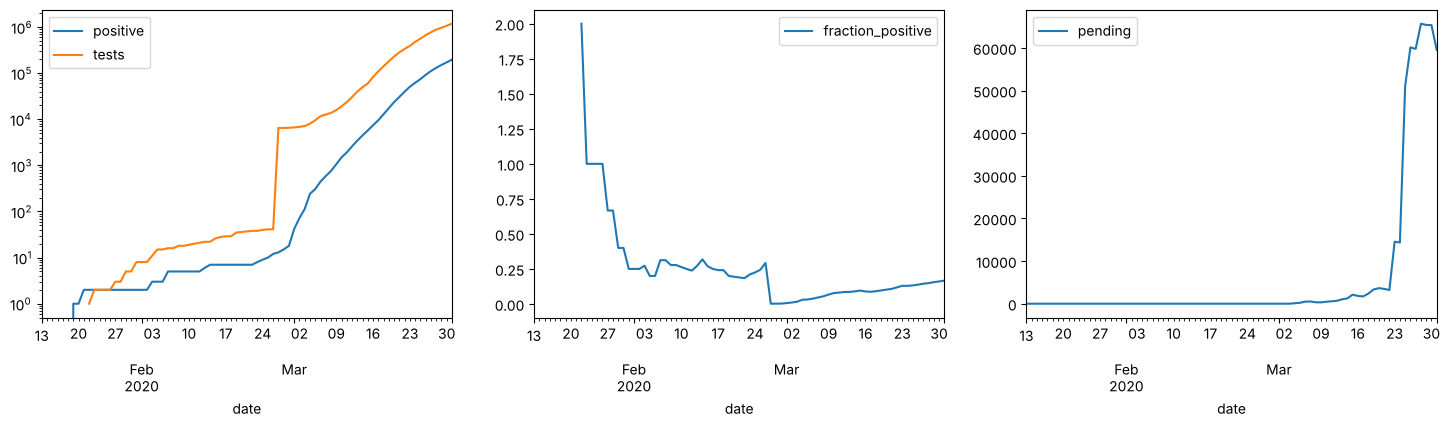

In [14]:
dfus["fraction_positive"] = dfus["positive"] / dfus["tests"]
fig, axes = plt.subplots(1, 3, figsize=[18, 4])
dfus.plot(x="date", y=["positive", "tests"], logy=True, ax=axes[0])
dfus.plot(x="date", y="fraction_positive", ax=axes[1])
dfus.plot(x="date", y="pending", ax=axes[2])
plt.show()